<a href="https://colab.research.google.com/github/MonKhach/Multivariate-Statistical-Analysis-of-Wine-Quality-Based-on-Physicochemical-Properties/blob/main/Multivariate_Statistical_Analysis_of_Wine_Quality_Based_on_Physicochemical_Properties.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2

In [ ]:
df = pd.read_csv('winequality-white.csv', sep=';')
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
5,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6
7,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
8,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
9,8.1,0.22,0.43,1.5,0.044,28.0,129.0,0.9938,3.22,0.45,11.0,6


In [ ]:
df.shape

(4898, 12)

In [ ]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [ ]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [ ]:
df.duplicated().sum()

np.int64(937)

In [ ]:
df["quality"].value_counts().sort_index()

,count
quality,
3,20
4,163
5,1457
6,2198
7,880
8,175
9,5


In [ ]:
df.skew(numeric_only=True).sort_values()

,0
quality,0.155796
total sulfur dioxide,0.390710
pH,0.457783
alcohol,0.487342
fixed acidity,0.647751
sulphates,0.977194
density,0.977773
residual sugar,1.077094
citric acid,1.281920
free sulfur dioxide,1.406745


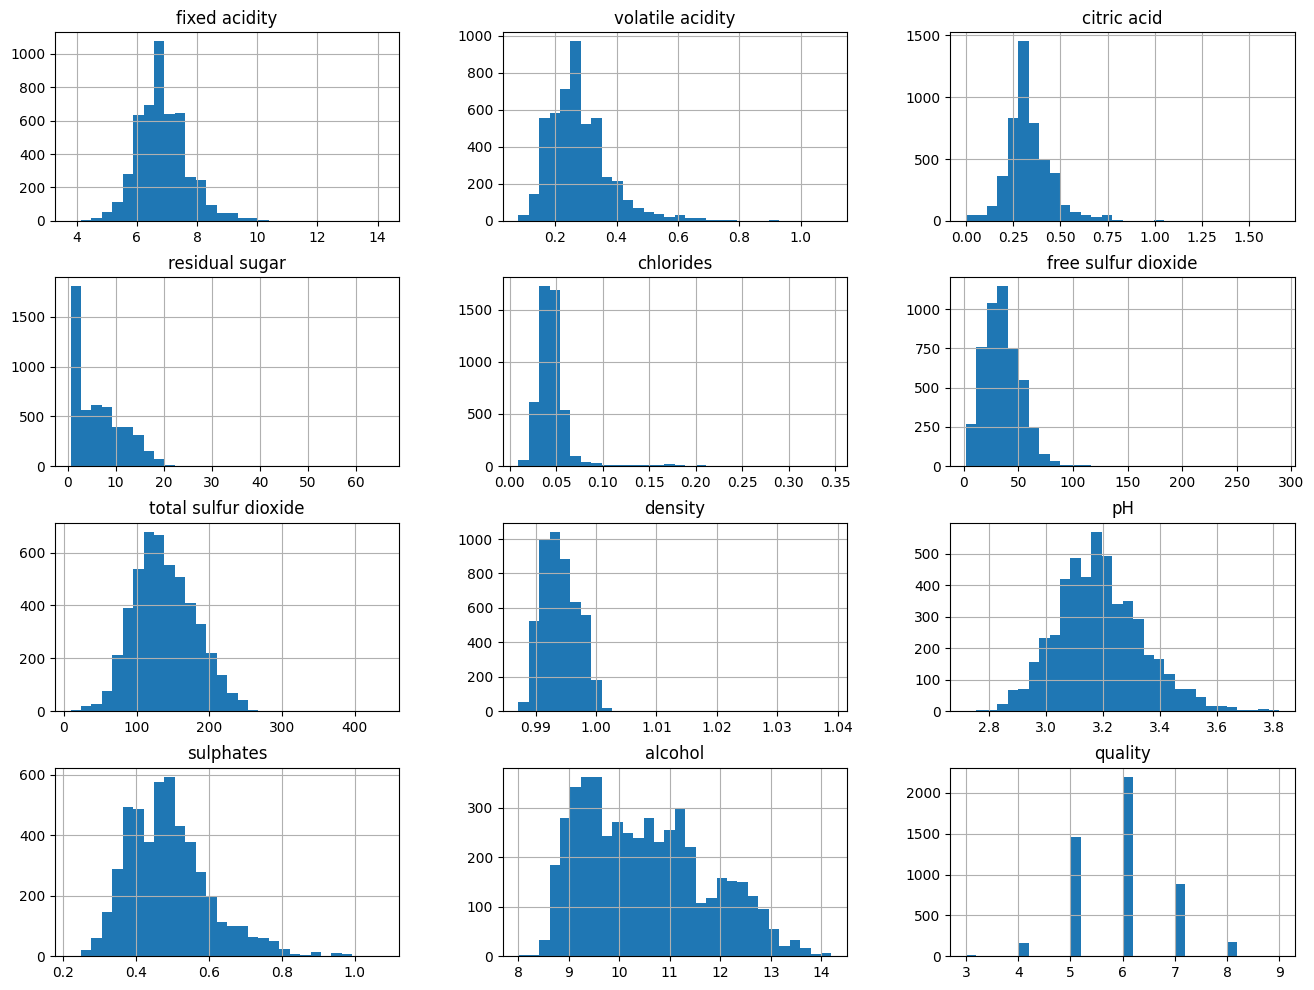

In [ ]:
df.hist(figsize=(16, 12), bins=30)
plt.tight_layout
plt.show()

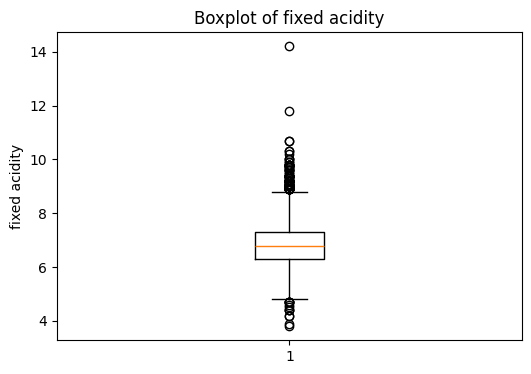

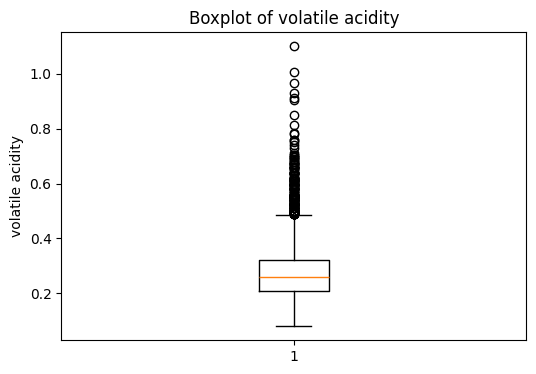

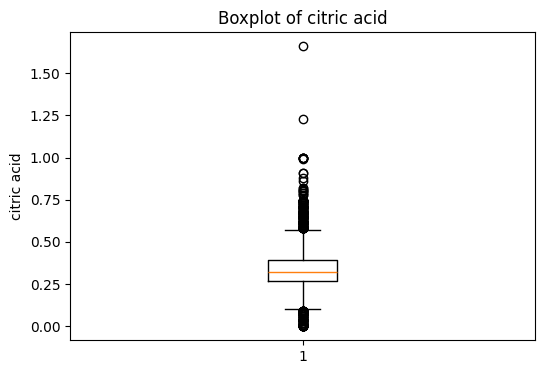

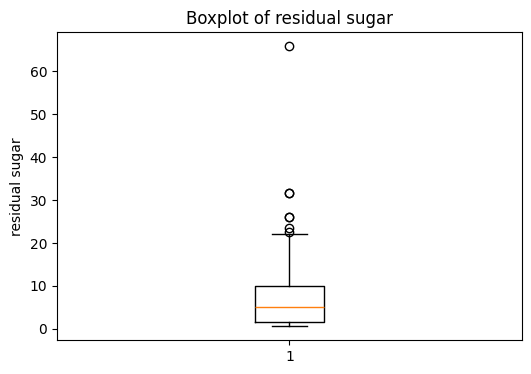

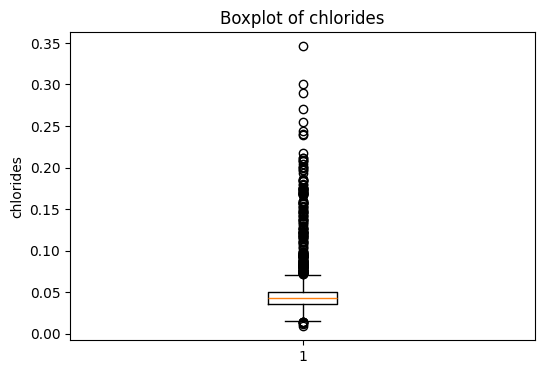

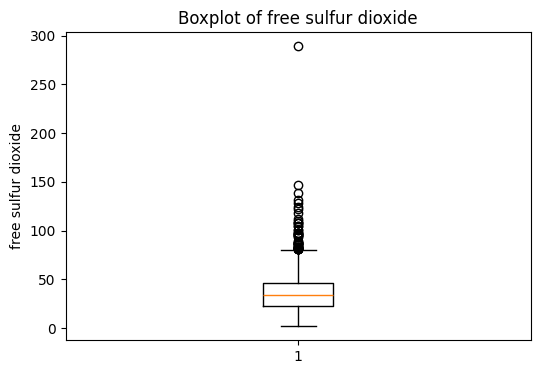

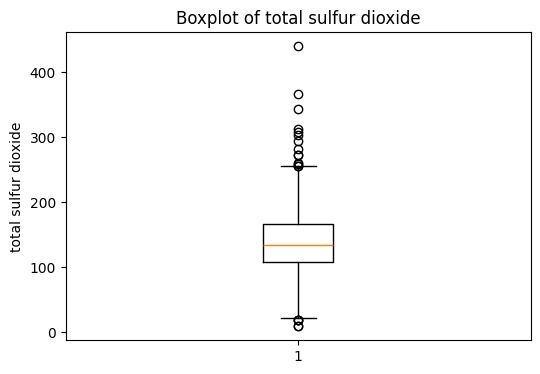

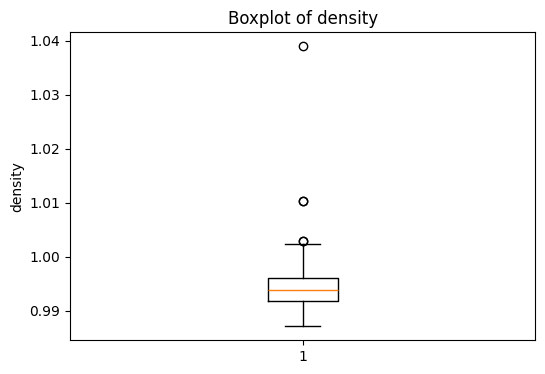

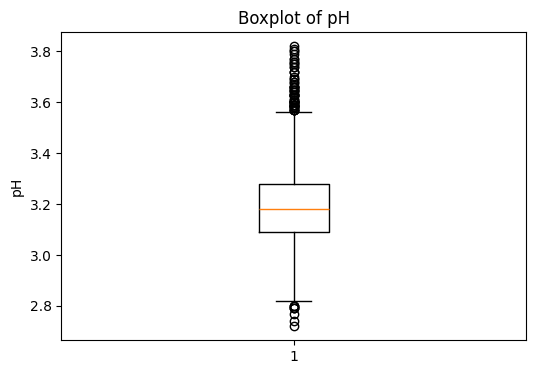

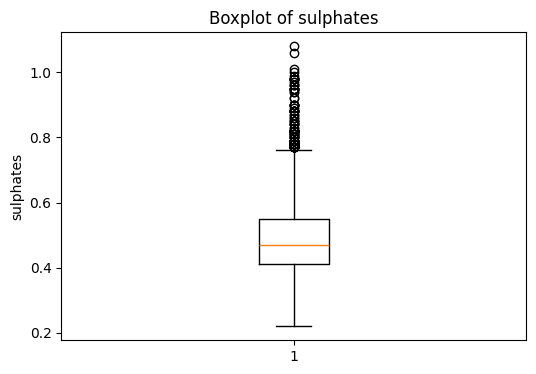

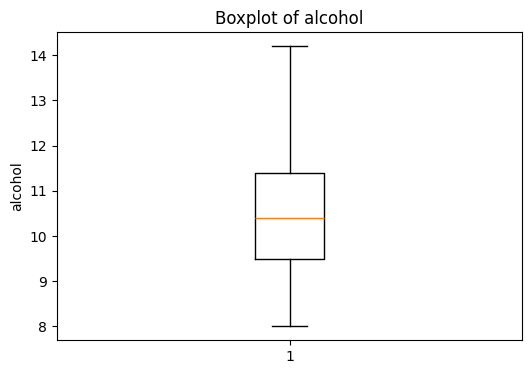

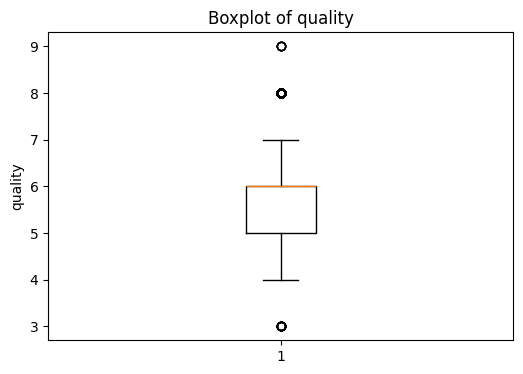

In [ ]:
for col in df.columns:
  plt.figure(figsize=(6,4))
  plt.boxplot(df[col])
  plt.title(f'Boxplot of {col}')
  plt.ylabel(col)
  plt.show()

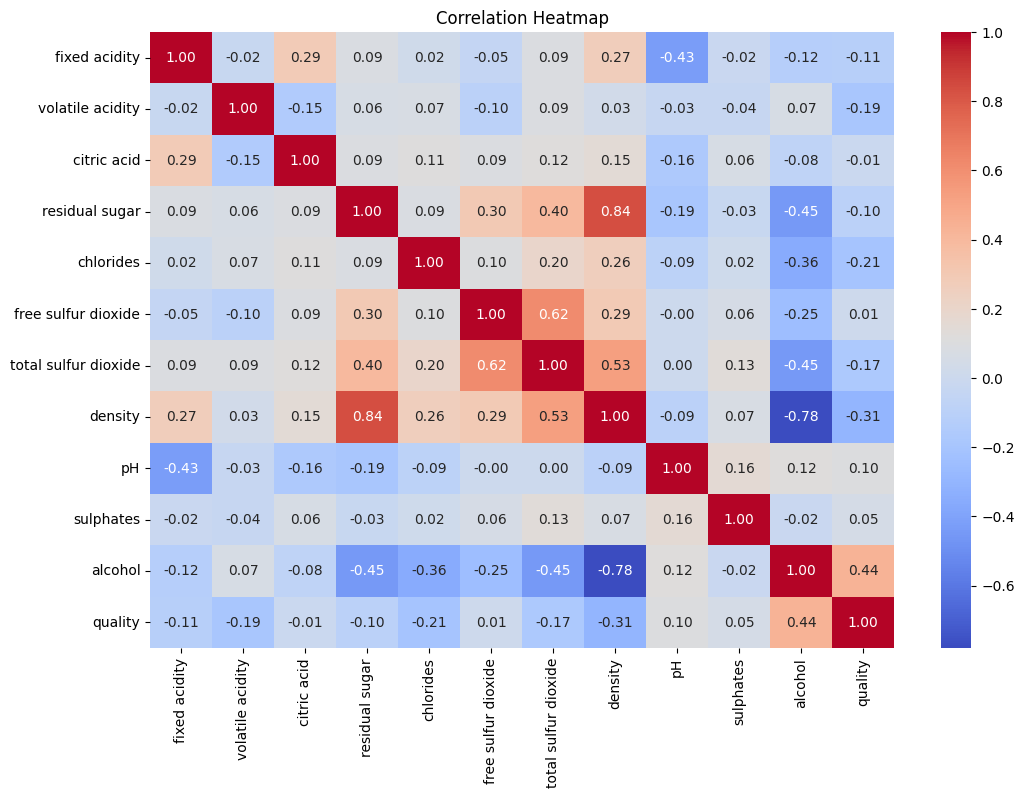

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

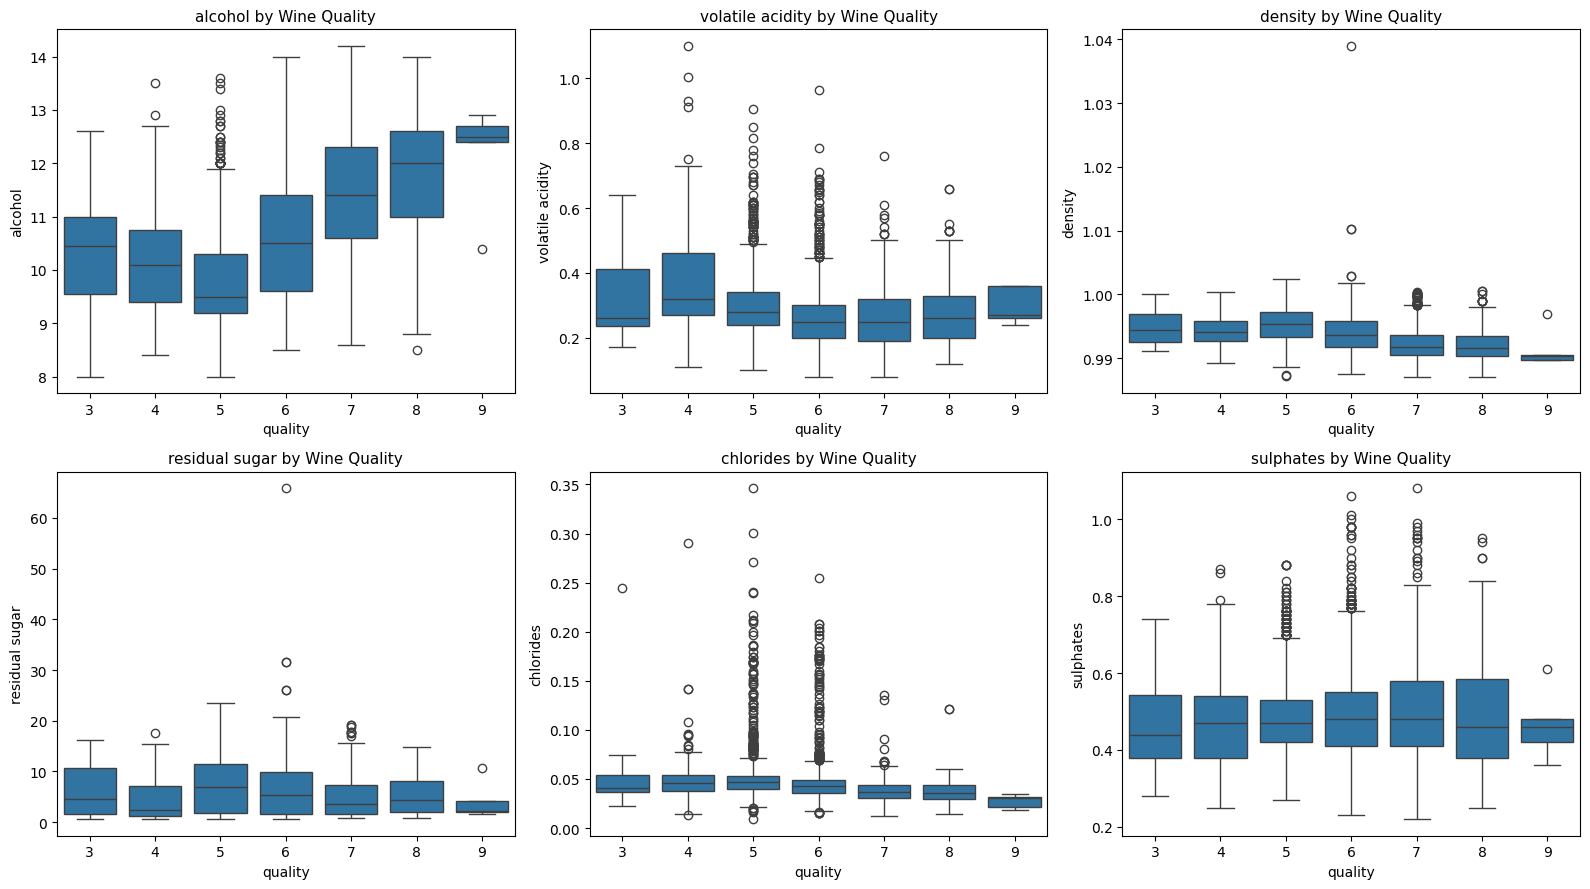

In [ ]:
selected_cols = [
    "alcohol",
    "volatile acidity",
    "density",
    "residual sugar",
    "chlorides",
    "sulphates"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.boxplot(data=df, x="quality", y=col, ax=axes[i])
    axes[i].set_title(f"{col} by Wine Quality", fontsize=11)
    axes[i].set_xlabel("quality")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

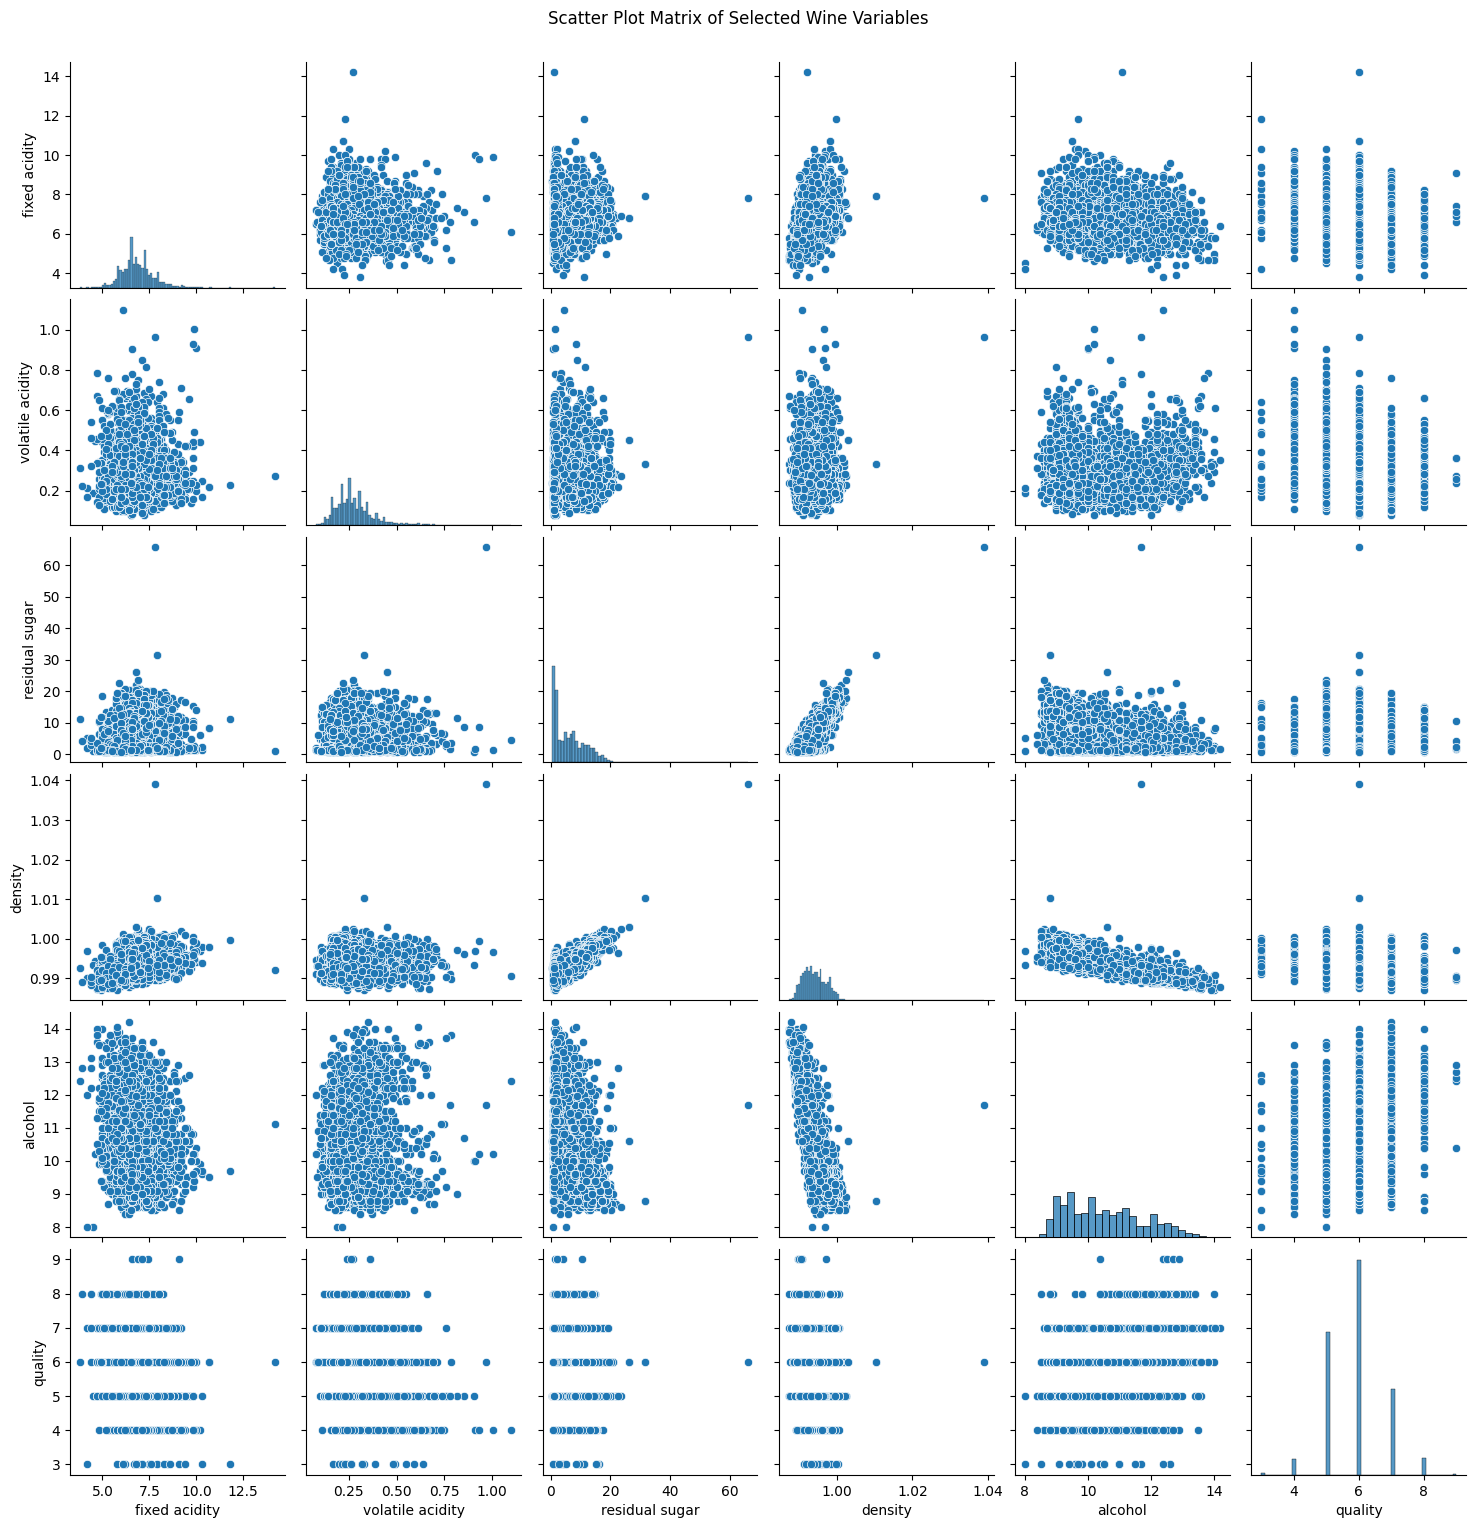

In [ ]:
selected_cols = [
    "fixed acidity",
    "volatile acidity",
    "residual sugar",
    "density",
    "alcohol",
    "quality"
]
sns.pairplot(df[selected_cols], diag_kind="hist")
plt.suptitle("Scatter Plot Matrix of Selected Wine Variables", y=1.02)
plt.show()

In [ ]:
X = df.drop('quality', axis=1)
y = df['quality']
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     174.3
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        07:26:33   Log-Likelihood:                -5543.7
No. Observations:                4898   AIC:                         1.111e+04
Df Residuals:                    4886   BIC:                         1.119e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  150.1928 

In [ ]:
def backward_elimination(X, y, significance_level=0.05):
    X_selected = sm.add_constant(X)

    while True:
        model = sm.OLS(y, X_selected).fit()
        p_values = model.pvalues.drop("const")
        max_p_value = p_values.max()

        if max_p_value > significance_level:
            excluded_variable = p_values.idxmax()
            X_selected = X_selected.drop(columns=[excluded_variable])
        else:
            break

    return model, X_selected.columns

selected_model, selected_variables = backward_elimination(X, y)

print(selected_variables)
print(selected_model.summary())

Index(['const', 'fixed acidity', 'volatile acidity', 'residual sugar',
       'free sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.281
Method:                 Least Squares   F-statistic:                     239.7
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        07:28:50   Log-Likelihood:                -5544.1
No. Observations:                4898   AIC:                         1.111e+04
Df Residuals:                    4889   BIC:                         1.116e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                          coef    std err    

In [ ]:
X = df.drop("quality", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.29293217, 0.14320363, 0.11106103, 0.09259294, 0.08848496,
       0.08534014, 0.06605437, 0.05448713, 0.03764942, 0.02631701,
       0.00187719])

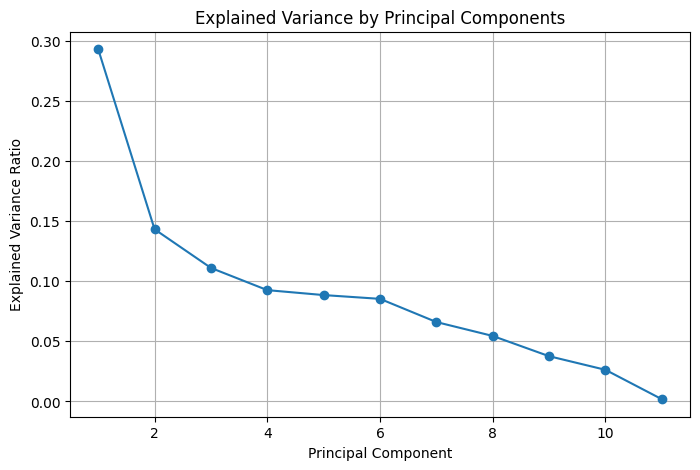

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")
plt.grid(True)
plt.show()

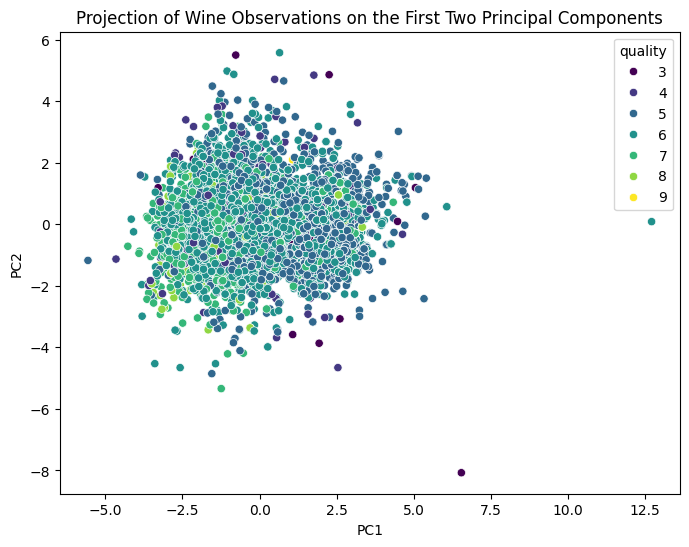

In [ ]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["quality"] = df["quality"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="quality", palette="viridis")
plt.title("Projection of Wine Observations on the First Two Principal Components")
plt.show()

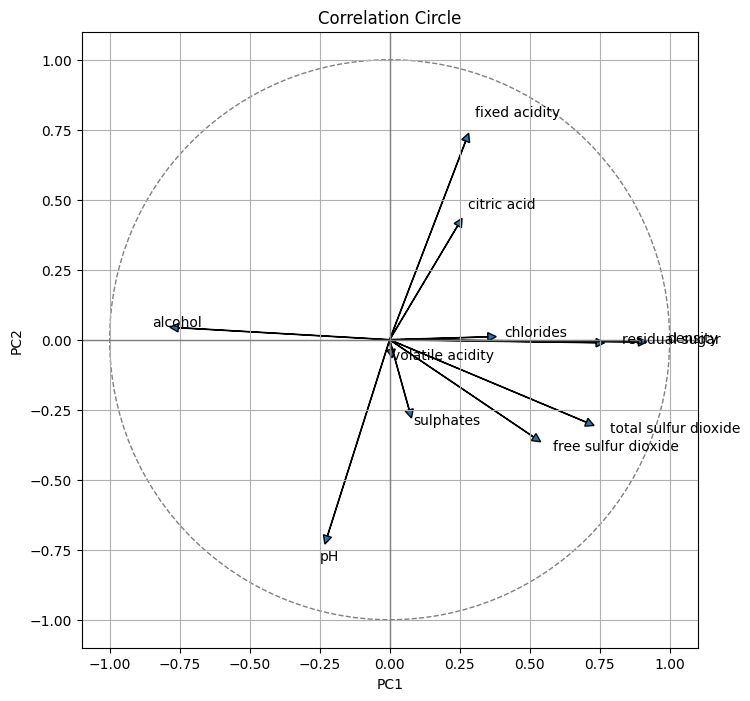

In [ ]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

features = X.columns

plt.figure(figsize=(8, 8))

circle = plt.Circle((0, 0), 1, color="gray", fill=False, linestyle="--")
plt.gca().add_artist(circle)

plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

for i, feature in enumerate(features):
    plt.arrow(
        0, 0,
        loadings[i, 0],
        loadings[i, 1],
        head_width=0.03,
        head_length=0.03,
        length_includes_head=True
    )
    plt.text(
        loadings[i, 0] * 1.08,
        loadings[i, 1] * 1.08,
        feature,
        fontsize=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Correlation Circle")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True)
plt.show()

In [ ]:
X_numeric = df.drop("quality", axis=1)

mean_vector = X_numeric.mean().values
cov_matrix = np.cov(X_numeric.values, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

mahal_dist = []

for row in X_numeric.values:
    dist = mahalanobis(row, mean_vector, inv_cov_matrix)
    mahal_dist.append(dist)

mahal_dist = np.array(mahal_dist)

# Squared Mahalanobis distances
mahal_dist_sq = mahal_dist ** 2

# Critical value for 11 variables at alpha = 0.001
critical_value = chi2.ppf(0.999, df=X_numeric.shape[1])

outliers = mahal_dist_sq > critical_value

print("Critical value:", critical_value)
print("Number of multivariate outliers:", outliers.sum())

Critical value: 31.264133620239985
Number of multivariate outliers: 137


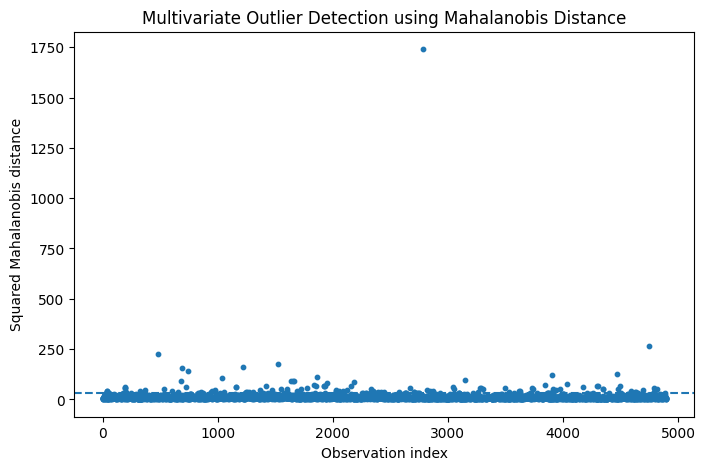

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(mahal_dist_sq)), mahal_dist_sq, s=10)
plt.axhline(critical_value, linestyle="--")
plt.xlabel("Observation index")
plt.ylabel("Squared Mahalanobis distance")
plt.title("Multivariate Outlier Detection using Mahalanobis Distance")
plt.show()